### 2 a) Incorporation of a third element: The $WK_3$ model
The 2-element model presents a limitation: it does not correctly model the pressure-flow relationship during the initial phase of systole (high frequencies). To correct this, a third parameter is incorporated: the **Aortic Characteristic Impedance ($Z_c$)**.

This element models the local and inertial resistance of the aortic root upon the arrival of the pulsatile flow wave, linking the lumped-parameter model with the wave transmission phenomena along the arterial tree.

Mathematically, $Z_c$ is placed in series with the system, so the total aortic pressure will be the sum of the pressure over the compliance ($P_c$, calculated the same as in $WK_2$) plus the instantaneous pressure drop generated by the flow when passing through $Z_c$ ($Q \cdot Z_c$).

In [1]:
# -------------------------------------------------------------------------
# GENERAL USE MODULES AND FLOW FUNCTION
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    Escala_ml = 1e5 * (Qmax / 8.8)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [2]:
# -------------------------------------------------------------------------
# SOLVERS FOR WK2 AND WK3
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = 80.0
    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)
    return P

def resolver_wk3_euler(Q, t, Ca, Rp, Zc):
    dt = t[1] - t[0]
    Pc = np.zeros(len(t))
    P_ao = np.zeros(len(t))

    Pc[0] = 80.0
    P_ao[0] = Pc[0] + (Q[0] * Zc)

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (Pc[i-1] / (Rp * Ca))
        Pc[i] = Pc[i-1] + (dP_dt * dt)
        P_ao[i] = Pc[i] + (Q[i] * Zc)

    return P_ao

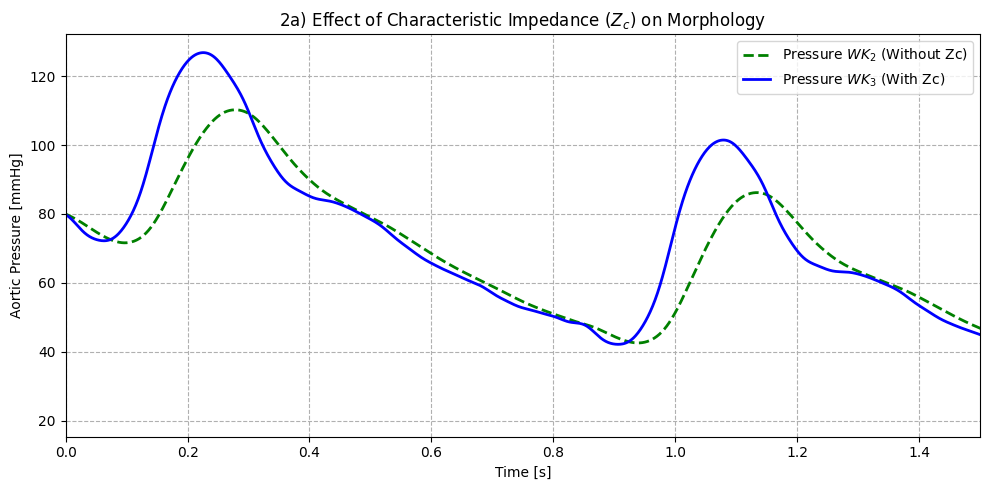

In [3]:
# -------------------------------------------------------------------------
# SIMULATION 2a: WK2 vs WK3
# -------------------------------------------------------------------------

Ts = 0.001
t = np.arange(0, 5, Ts)
T0 = 0.85
Qmax = 500
Q_entrada = Q_Sim(Qmax, T0, t)

Ca_basal = 1.1
Rp_basal = 0.9
Zc_basal = 0.06

P_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_basal, Rp_basal)
P_wk3 = resolver_wk3_euler(Q_entrada, t, Ca_basal, Rp_basal, Zc_basal)

plt.figure(figsize=(10, 5))
plt.plot(t, P_wk2, '--', color='green', linewidth=2, label='Pressure $WK_2$ (Without Zc)')
plt.plot(t, P_wk3, color='blue', linewidth=2, label='Pressure $WK_3$ (With Zc)')
plt.xlim(0, 1.5) # Zoom to the first beats
plt.xlabel('Time [s]')
plt.ylabel('Aortic Pressure [mmHg]')
plt.title('2a) Effect of Characteristic Impedance ($Z_c$) on Morphology')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion of the analysis (2 a)
When comparing the morphologies, we observe that the incorporation of the **Characteristic Impedance ($Z_c$)** solves an obvious anomaly of the $WK_2$ model.

In the $WK_2$ model (dotted green line), the pressure rises very smoothly and "filtered" during systole. However, in the $WK_3$ model (blue line), the pressure curve exhibits a **much steeper ascending slope** at the beginning of systole, followed by a more defined peak. This occurs because the term $Q(t) \cdot Z_c$ couples the abrupt shape of the flow wave (high frequencies) directly to the pressure signal. This behavior is much more faithful to actual invasive recordings measured in the human aortic root.